In [1]:
!pip install scikit-fuzzy scipy numpy packaging networkx matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import skfuzzy as fuzz
import pandas as hayo
from skfuzzy import control as ctrl
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
terjual = ctrl.Antecedent(np.arange(0, 100, 1), 'terjual')
permintaan = ctrl.Antecedent(np.arange(0, 300, 1), 'permintaan')
harga = ctrl.Antecedent(np.arange(0, 100000, 1), 'harga')
profit = ctrl.Antecedent(np.arange(0, 4000000, 1), 'profit')
stok = ctrl.Consequent(np.arange(0, 1000, 1), 'stok')

terjual['rendah'] = fuzz.trimf(terjual.universe, [0, 0, 40])
terjual['sedang'] = fuzz.trimf(terjual.universe, [30, 50, 70])
terjual['tinggi'] = fuzz.trimf(terjual.universe, [60, 100, 100])

permintaan['rendah'] = fuzz.trimf(permintaan.universe, [0,0,100])
permintaan['sedang'] = fuzz.trimf(permintaan.universe, [50,150,250])
permintaan['tinggi'] = fuzz.trimf(permintaan.universe, [200,300,300])

harga['murah'] = fuzz.trimf(harga.universe, [0,0,40000])
harga['sedang'] = fuzz.trimf(harga.universe, [30000,50000,80000])
harga['mahal'] = fuzz.trimf(harga.universe, [60000,100000,100000])

profit['rendah'] = fuzz.trimf(profit.universe, [0,0,1000000])
profit['sedang'] = fuzz.trimf(profit.universe, [1000000,2000000,2500000])
profit['tinggi'] = fuzz.trapmf(profit.universe, [1500000,2500000,4000000,4000000])

stok['sedang'] = fuzz.trimf(stok.universe, [100,500,900])
stok['banyak'] = fuzz.trimf(stok.universe, [600,1000,1000])


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


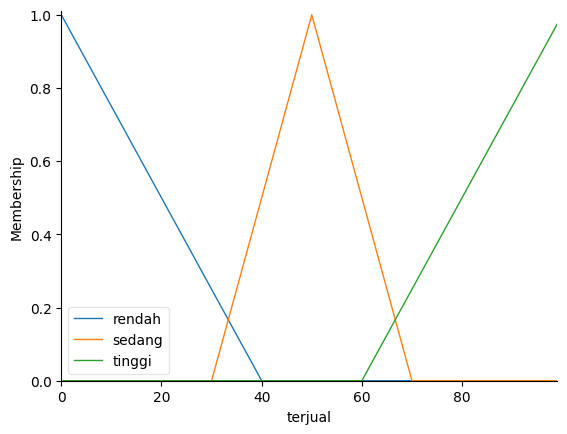

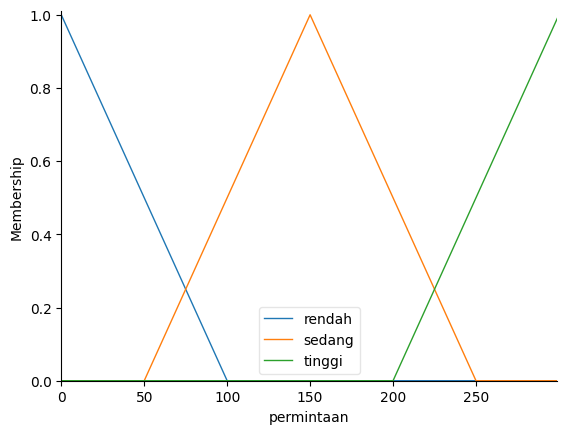

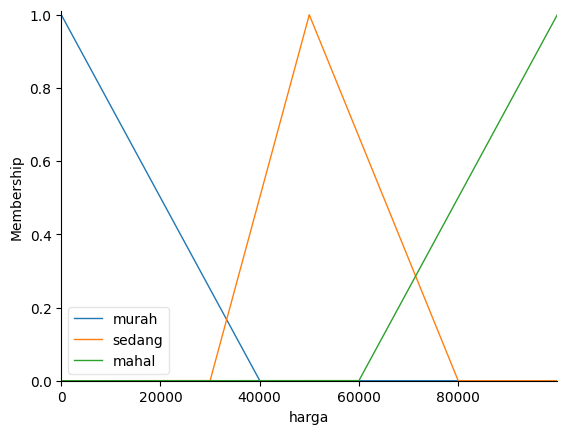

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


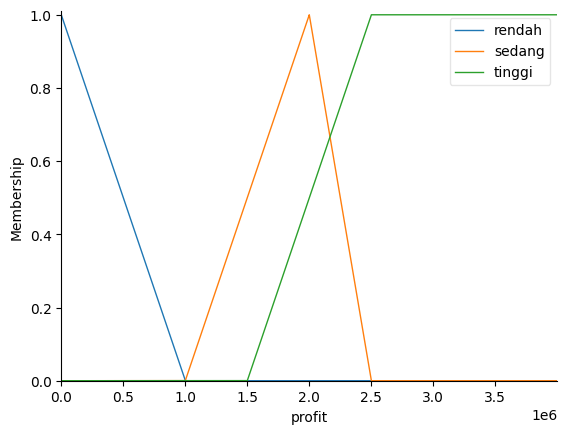

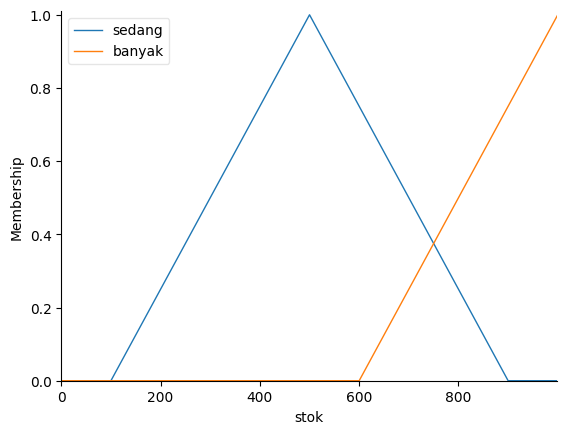

In [4]:
terjual.view()
permintaan.view()
harga.view()
profit.view()
stok.view()

834.1064814814815


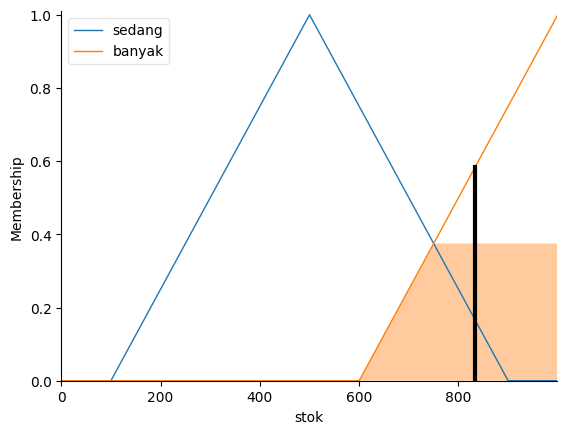

In [5]:
mesin = ctrl.ControlSystem([
    ctrl.Rule(terjual['tinggi'] & permintaan['tinggi'] & harga['murah'] & profit['tinggi'], stok['banyak']),
    ctrl.Rule(terjual['tinggi'] & permintaan['tinggi'] & harga['murah'] & profit['sedang'], stok['sedang']),
    ctrl.Rule(terjual['tinggi'] & permintaan['sedang'] & harga['murah'] & profit['sedang'], stok['sedang']),
    ctrl.Rule(terjual['sedang'] & permintaan['tinggi'] & harga['murah'] & profit['sedang'], stok['sedang']),
    ctrl.Rule(terjual['sedang'] & permintaan['tinggi'] & harga['murah'] & profit['tinggi'], stok['banyak']),
    ctrl.Rule(terjual['rendah'] & permintaan['rendah'] & harga['sedang'] & profit['sedang'], stok['sedang'])
  ])
sistem = ctrl.ControlSystemSimulation(mesin)
sistem.input['terjual'] = 80
sistem.input['permintaan'] = 255
sistem.input['harga'] = 25000
sistem.input['profit'] = 3500000
sistem.compute()
print(sistem.output['stok'])
stok.view(sim = sistem)


In [6]:
informasi = ctrl.Antecedent(np.arange(0, 100, 1), 'informasi')
syarat = ctrl.Antecedent(np.arange(0, 100, 1), 'syarat')
petugas = ctrl.Antecedent(np.arange(0, 100, 1), 'petugas')
sarpras = ctrl.Antecedent(np.arange(0, 100, 1), 'sarpras')
pelayanan = ctrl.Consequent(np.arange(0, 400, 1), 'pelayanan')

informasi['Tidak Memuaskan'] = fuzz.trapmf(informasi.universe, [0,0,60,75])
informasi['Cukup Memuaskan'] = fuzz.trimf(informasi.universe, [60,75,90])
informasi['Memuaskan'] = fuzz.trapmf(informasi.universe, [75,90,100,100])

syarat['Tidak Memuaskan'] = fuzz.trapmf(syarat.universe, [0,0,60,75])
syarat['Cukup Memuaskan'] = fuzz.trimf(syarat.universe, [60,75,90])
syarat['Memuaskan'] = fuzz.trapmf(syarat.universe, [75,90,100,100])

petugas['Tidak Memuaskan'] = fuzz.trapmf(petugas.universe, [0,0,60,75])
petugas['Cukup Memuaskan'] = fuzz.trimf(petugas.universe, [60,75,90])
petugas['Memuaskan'] = fuzz.trapmf(petugas.universe, [75,90,100,100])

sarpras['Tidak Memuaskan'] = fuzz.trapmf(sarpras.universe, [0,0,60,75])
sarpras['Cukup Memuaskan'] = fuzz.trimf(sarpras.universe, [60,75,90])
sarpras['Memuaskan'] = fuzz.trapmf(sarpras.universe, [75,90,100,100])

pelayanan['Tidak Memuaskan'] = fuzz.trapmf(pelayanan.universe, [0,0,50,75])
pelayanan['Kurang Memuaskan'] = fuzz.trapmf(pelayanan.universe, [50,75,100,150])
pelayanan['Cukup Memuaskan'] = fuzz.trapmf(pelayanan.universe, [100,150,250,275])
pelayanan['Memuaskan'] = fuzz.trapmf(pelayanan.universe, [250,275,325,350])
pelayanan['Sangat Memuaskan'] = fuzz.trapmf(pelayanan.universe, [325,350,400,400])

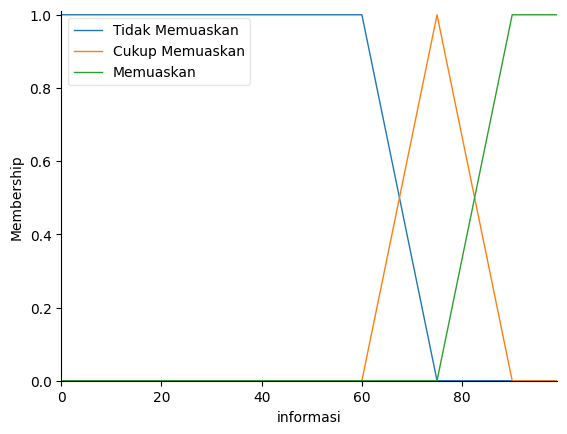

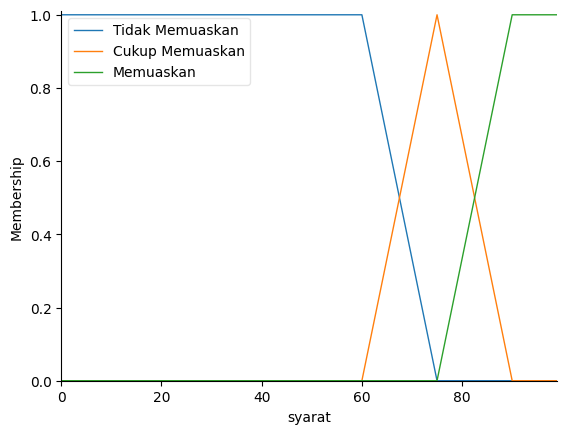

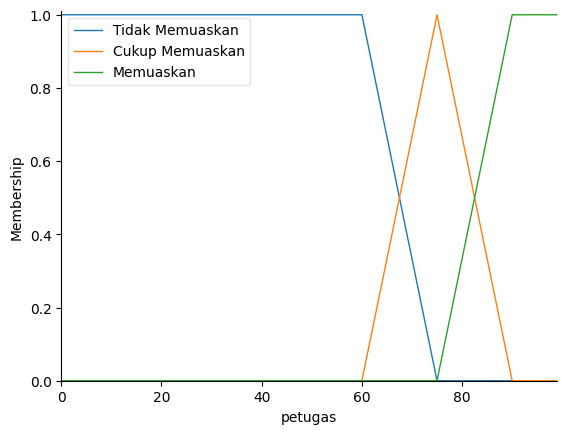

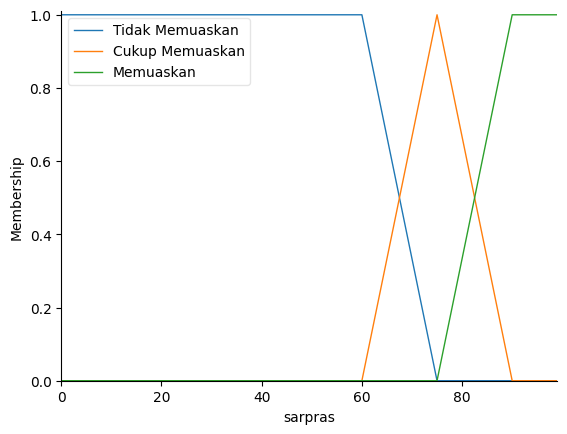

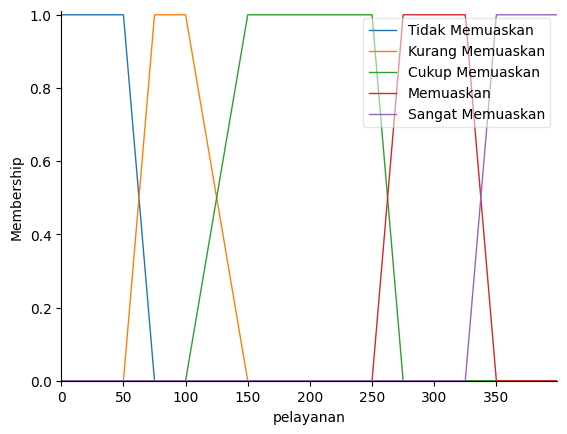

In [7]:
informasi.view()
syarat.view()
petugas.view()
sarpras.view()
pelayanan.view()

In [10]:
aturan = hayo.read_csv('/content/drive/MyDrive/H1D024005-PraktikumKB-Pertemuan3/81_fuzzy_rules.csv')

In [11]:
regulasi = [ctrl.Rule( \
    informasi[aturan['Kejelasan Informasi'][rule]] & \
    syarat[aturan['Kejelasan Persyaratan'][rule]] & \
    petugas[aturan['Kemampuan Petugas'][rule]] & \
    sarpras[aturan['Ketersediaan Sarpras'][rule]], pelayanan[aturan['Kepuasan Pelayanan'][rule]]
    ) for rule in range(len(aturan))]

214.81665442018888


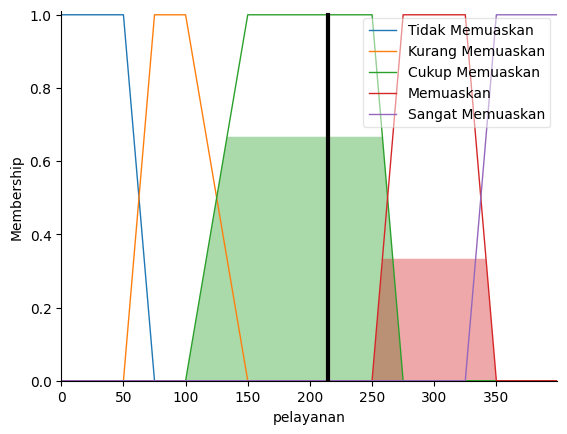

In [13]:
mesin2 = ctrl.ControlSystem(regulasi)
sistem2 = sistem = ctrl.ControlSystemSimulation(mesin2)

sistem2.input['informasi'] = 80
sistem2.input['syarat'] = 60
sistem2.input['petugas'] = 50
sistem2.input['sarpras'] = 90
sistem2.compute()
print(sistem2.output['pelayanan'])
pelayanan.view(sim = sistem2)
